# Workshop 1 : Image Processing

## 2.1 Exercise - 1

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

### 1. Read and display the image
Reading the image using **Pillow** library.

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

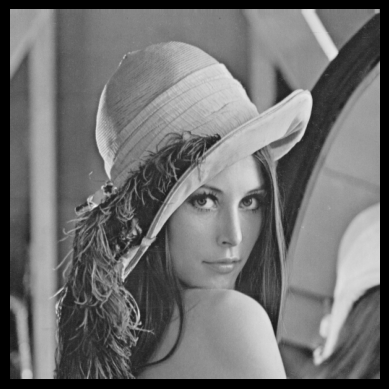

In [89]:
image = Image.open("lena_gray.gif").convert("RGB")

plt.imshow(image)
plt.axis('off')

### 2. Display only the top left corner of 100x100 pixels

(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

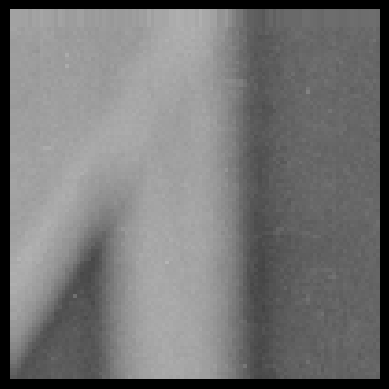

In [90]:
img_array = np.array(image)
top_left = img_array[:100, :100]

plt.imshow(top_left)
plt.axis('off')

### 3. Show the three color channels (R, G, B)

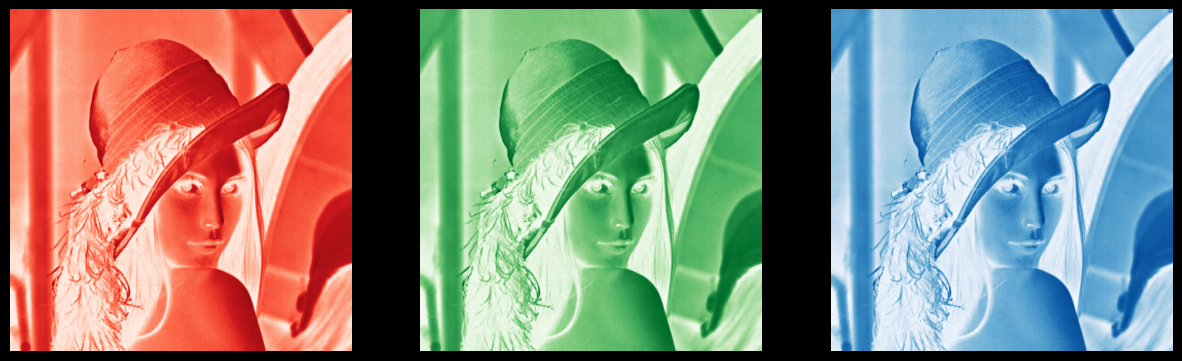

In [91]:
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(R, cmap='Reds')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(G, cmap='Greens')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(B, cmap='Blues')
plt.axis('off')

plt.show()

### 4. Modify the top 100x100 pixels to a value of 210

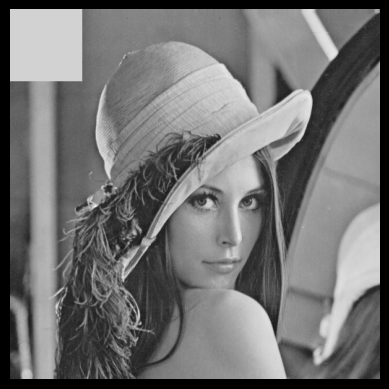

In [92]:
modified_img = img_array.copy()
modified_img[:100, :100] = 210

plt.imshow(modified_img)
plt.axis('off')
plt.show()

## 2.2 Exercise - 2

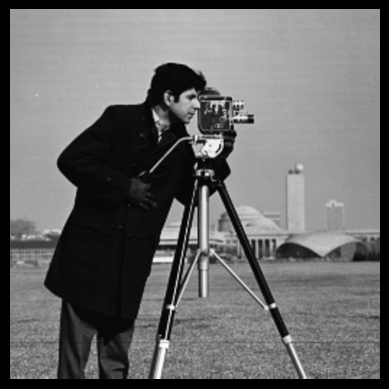

In [93]:
gray_image = Image.open("cameraman.png").convert("L")

plt.imshow(gray_image, cmap='gray')
plt.axis('off')
plt.show()

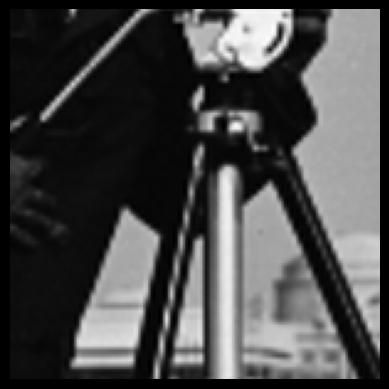

In [75]:
gray_array = np.array(gray_image)
h, w = gray_array.shape
start_h, start_w = h // 2 - 75, w // 2 - 75
middle_section = gray_array[start_h:start_h+150, start_w:start_w+150]

plt.imshow(middle_section, cmap='gray')
plt.axis('off')
plt.show()

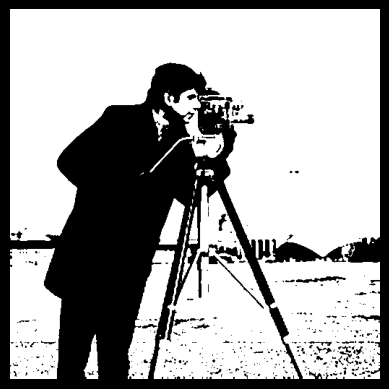

In [76]:
thresholded = np.where(gray_array < 100, 0, 255)

plt.imshow(thresholded, cmap='gray')
plt.axis('off')
plt.show()

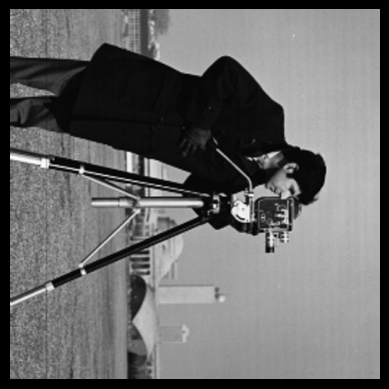

In [77]:
rotated_image = gray_image.rotate(-90)

plt.imshow(rotated_image, cmap='gray')
plt.axis('off')
plt.show()

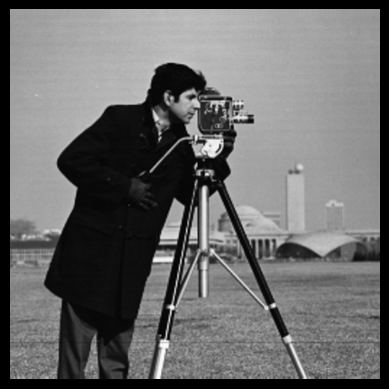

In [78]:
rgb_converted = np.stack([gray_array] * 3, axis=-1)

plt.imshow(rgb_converted)
plt.axis('off')
plt.show()

## Exercise 3

In [79]:
img_gray = Image.open("lena_gray.gif").convert("L")
img_arr = np.array(img_gray, dtype=float)

In [80]:
mean_centered_data = img_arr - np.mean(img_arr, axis=0)

In [81]:
cov_matrix = np.cov(mean_centered_data, rowvar=False)

In [82]:
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)

In [83]:
sorted_index = np.argsort(eigen_values)[::-1]
sorted_eigenvalue = eigen_values[sorted_index]
sorted_eigenvectors = eigen_vectors[:, sorted_index]

In [84]:
cumulative_variance = np.cumsum(sorted_eigenvalue) / np.sum(sorted_eigenvalue)

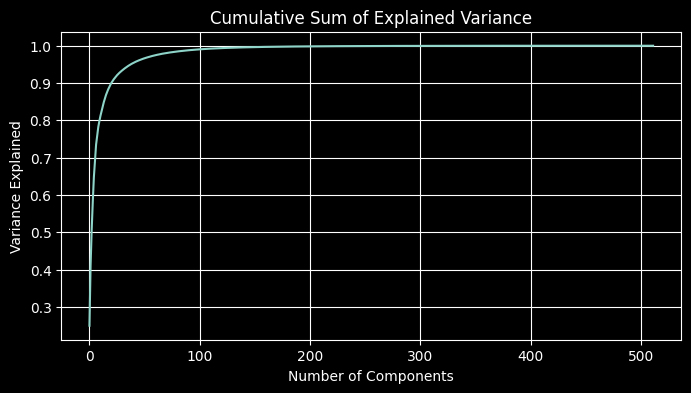

In [85]:
plt.figure(figsize=(8, 4))
plt.plot(cumulative_variance)
plt.title('Cumulative Sum of Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.grid()
plt.show()

In [94]:
def compress_decompress(data, components, sorted_eigenvectors, original_mean):
    subset_vectors = sorted_eigenvectors[:, :components]
    transformed_data = np.dot(data, subset_vectors)

    reconstructed_data = np.dot(transformed_data, subset_vectors.T) + original_mean
    return reconstructed_data

In [87]:
component_list = [10, 20, 50, 100]
original_mean = np.mean(img_arr, axis=0)

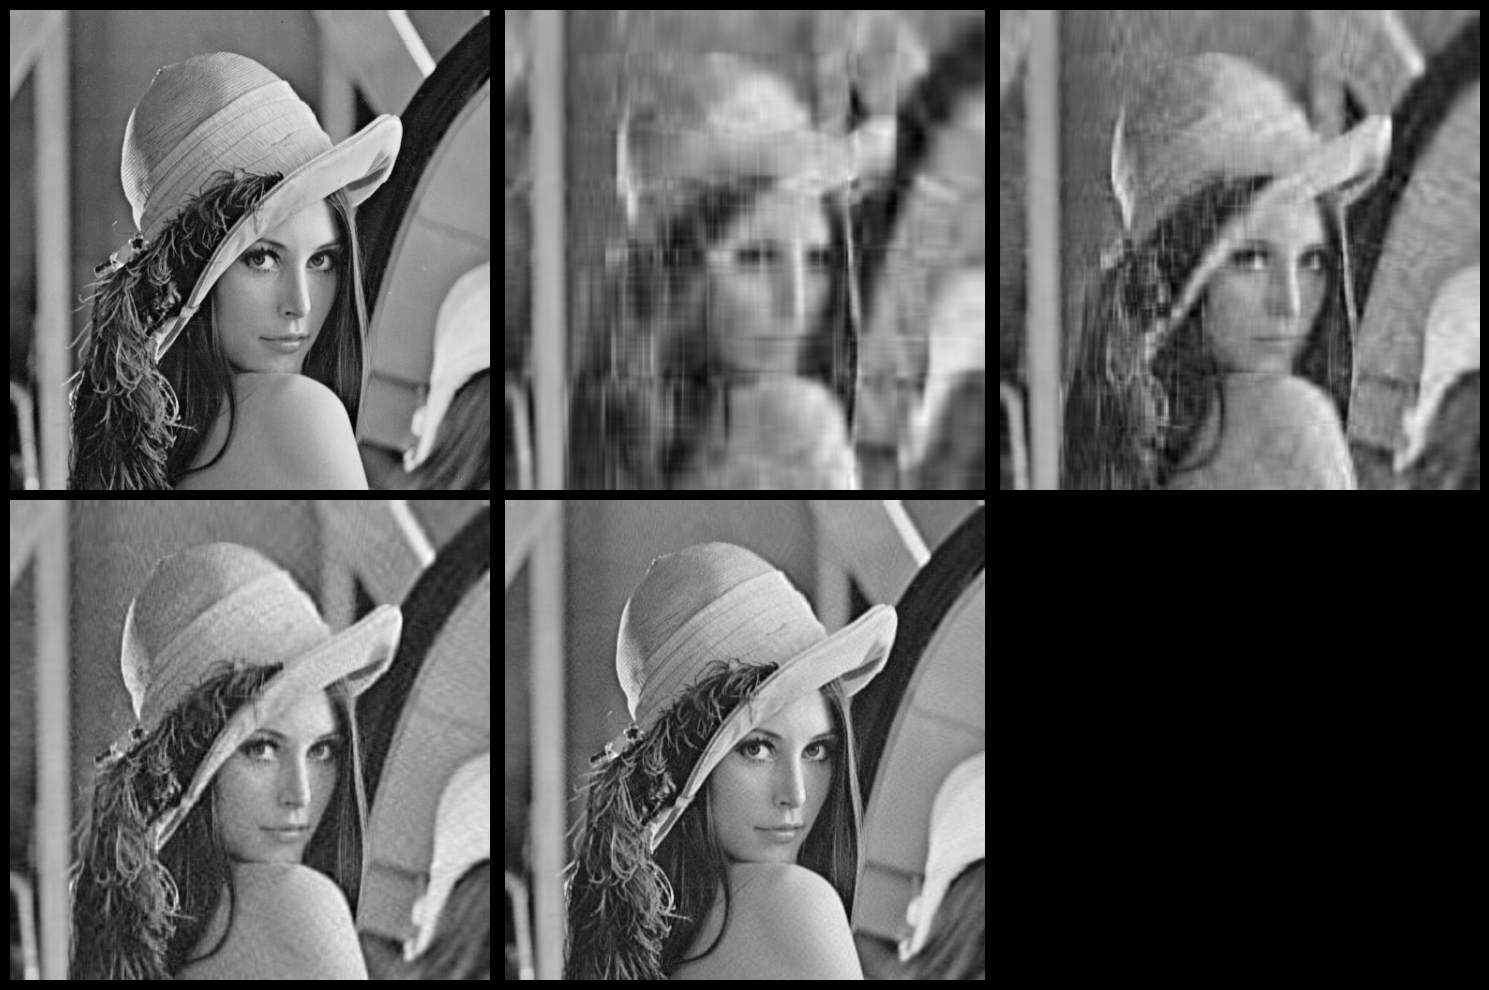

In [88]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
plt.imshow(img_arr, cmap='gray')
plt.axis('off')

for i, k in enumerate(component_list):
    reconstructed = compress_decompress(mean_centered_data, k, sorted_eigenvectors, original_mean)

    plt.subplot(2, 3, i+2)
    plt.imshow(reconstructed, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()